
# Options Data Quality Check

This notebook checks whether raw option quote data is good enough for:

1. computing implied volatilities,
2. fitting an implied volatility surface,
3. testing/using an arbitrage-free volatility surface model,
4. later hedging experiments.

The expected input is a `pandas` DataFrame with columns like:

```python
['date', 'expiry', 'strike', 'option_type', 'market_price', 'volume', 'open_interest', 'underlying_price']
```

You may need to rename columns depending on your data source.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)



## 1. Load data

Replace the path and column names with your own.


In [6]:
df = pd.read_csv("data/AAPL_options_2026-05-10_2026-06-10.csv")
df.head()

,underlying,contract,type,strike,expiration,date,open,high,low,close,volume,vwap,transactions
0,AAPL,O:AAPL260511C00262500,call,262.5,2026-05-11,2026-05-11,30.85,30.85,29.33,29.59,5,29.8700,5
1,AAPL,O:AAPL260511C00265000,call,265.0,2026-05-11,2026-05-11,28.54,28.54,25.35,26.16,26,26.4246,7
2,AAPL,O:AAPL260511C00267500,call,267.5,2026-05-11,2026-05-11,23.30,26.14,23.30,24.58,5,24.6420,4
3,AAPL,O:AAPL260511C00270000,call,270.0,2026-05-11,2026-05-11,23.49,23.49,21.15,21.92,5,21.9320,5
4,AAPL,O:AAPL260511C00272500,call,272.5,2026-05-11,2026-05-11,18.45,20.50,18.45,18.69,9,18.9567,4


In [7]:
# Rename columns for convenience

df = df.rename(columns={
    "type": "option_type",
    "expiration": "expiry",
    "close": "market_price"
})

# Remove the column "underlying" as all entries are the same

df = df.drop(columns='underlying')

# Convert date to pandas DateTime

df['date'] = pd.to_datetime(df['date']).dt.date


In [29]:
print(f"Data ranges between {df['date'].sort_values()[0]} to {df['date'].sort_values()[len(df)-1]}")
print(f"We have options data for {df['date'].nunique()} days")

Data ranges between 2026-05-11 to 2026-06-09
We have options data for 21 days


In [30]:
required_cols = [
    "date", "expiry", "strike", "option_type",
    "market_price", "underlying_price"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    print("Missing columns:", missing)
else:
    print("All required columns are present.")


Missing columns: ['underlying_price']


In [31]:
# Get underlying_price, which is the stock price of AAPL

import yfinance as yf

aapl = yf.download(
    "AAPL",
    start=df["date"].min(),
    end=df["date"].max() + pd.Timedelta(days=1),
    auto_adjust=True
)

aapl = aapl.reset_index()[["Date", "Close"]]
aapl.columns = ["date", "underlying_price"]

df["date"] = pd.to_datetime(df["date"]).dt.normalize()
aapl["date"] = pd.to_datetime(aapl["date"]).dt.normalize()

df = df.merge(aapl, on="date", how="left")
df.head()

[*********************100%***********************]  1 of 1 completed


,contract,option_type,strike,expiry,date,open,high,low,market_price,volume,vwap,transactions,underlying_price
0,O:AAPL260511C00262500,call,262.5,2026-05-11,2026-05-11,30.85,30.85,29.33,29.59,5,29.8700,5,292.679993
1,O:AAPL260511C00265000,call,265.0,2026-05-11,2026-05-11,28.54,28.54,25.35,26.16,26,26.4246,7,292.679993
2,O:AAPL260511C00267500,call,267.5,2026-05-11,2026-05-11,23.30,26.14,23.30,24.58,5,24.6420,4,292.679993
3,O:AAPL260511C00270000,call,270.0,2026-05-11,2026-05-11,23.49,23.49,21.15,21.92,5,21.9320,5,292.679993
4,O:AAPL260511C00272500,call,272.5,2026-05-11,2026-05-11,18.45,20.50,18.45,18.69,9,18.9567,4,292.679993


In [33]:
df["underlying_price"].nunique()

21


## 2. Standardize data types

We convert dates, numeric columns, and option type labels.


In [6]:

df = df.copy()

df["date"] = pd.to_datetime(df["date"])
df["expiry"] = pd.to_datetime(df["expiry"])

numeric_cols = ["strike", "market_price", "underlying_price"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["option_type"] = df["option_type"].str.lower().str.strip()

df["T"] = (df["expiry"] - df["date"]).dt.total_seconds() / (365.25 * 24 * 3600)
df["moneyness"] = df["strike"] / df["underlying_price"]
df["log_moneyness"] = np.log(df["strike"] / df["underlying_price"])

df.head()


,contract,option_type,strike,expiry,date,open,high,low,market_price,volume,vwap,transactions,underlying_price,T,moneyness,log_moneyness
0,O:AAPL260511C00262500,call,262.5,2026-05-11,2026-05-11,30.85,30.85,29.33,29.59,5,29.8700,5,292.679993,0.0,0.896884,-0.108829
1,O:AAPL260511C00265000,call,265.0,2026-05-11,2026-05-11,28.54,28.54,25.35,26.16,26,26.4246,7,292.679993,0.0,0.905426,-0.099350
2,O:AAPL260511C00267500,call,267.5,2026-05-11,2026-05-11,23.30,26.14,23.30,24.58,5,24.6420,4,292.679993,0.0,0.913967,-0.089960
3,O:AAPL260511C00270000,call,270.0,2026-05-11,2026-05-11,23.49,23.49,21.15,21.92,5,21.9320,5,292.679993,0.0,0.922509,-0.080658
4,O:AAPL260511C00272500,call,272.5,2026-05-11,2026-05-11,18.45,20.50,18.45,18.69,9,18.9567,4,292.679993,0.0,0.931051,-0.071441



## 3. Basic sanity checks

These are quote-level checks. Bad data here usually means we should clean before computing implied volatilities.


In [7]:

checks = pd.DataFrame({
    "rows": [len(df)],
    "missing_strike": [df["strike"].isna().sum()],
    "missing_underlying": [df["underlying_price"].isna().sum()],
    "nonpositive_strike": [(df["strike"] <= 0).sum()],
    "nonpositive_underlying": [(df["underlying_price"] <= 0).sum()],
    "expired_or_zero_T": [(df["T"] <= 0).sum()],
    "nonpositive_market": [(df["market_price"] <= 0).sum()],
})
checks.T.rename(columns={0: "count"})


,count
rows,8725
missing_strike,0
missing_underlying,0
nonpositive_strike,0
nonpositive_underlying,0
expired_or_zero_T,541
nonpositive_market,0



## 4. Initial cleaning filter

This is intentionally conservative. Keep a separate raw copy before filtering.


In [8]:

raw_df = df.copy()

clean = df[
    (df["strike"] > 0) &
    (df["underlying_price"] > 0) &
    (df["T"] > 0) &
    (df["market_price"] > 0) &
    (df["option_type"].isin(["call", "put", "c", "p"]))
].copy()

clean["option_type"] = clean["option_type"].replace({"c": "call", "p": "put"})

print(f"Raw rows: {len(raw_df):,}")
print(f"Clean rows after basic filters: {len(clean):,}")
print(f"Removed rows: {len(raw_df) - len(clean):,}")


Raw rows: 8,725
Clean rows after basic filters: 8,184
Removed rows: 541



## 5. Liquidity and spread checks

Zero volume, or zero open interest may make implied volatility noisy.

Typical filters:
- remove very cheap options,
- remove extremely far OTM/ITM options,
- optionally require positive volume or open interest.


In [9]:

summary_cols = ["market_price", "T", "moneyness", "log_moneyness"]
clean[summary_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])


,market_price,T,moneyness,log_moneyness
count,8184.000000,8184.000000,8184.000000,8184.000000
mean,10.754370,0.071435,0.960503,-0.041854
std,11.775555,0.084317,0.053482,0.055865
min,0.010000,0.002738,0.839973,-0.174385
1%,0.020000,0.002738,0.851460,-0.160802
5%,0.080000,0.005476,0.874296,-0.134337
25%,1.290000,0.019165,0.918584,-0.084922
50%,6.325000,0.038330,0.961730,-0.039022
75%,16.715000,0.087611,1.003184,0.003179
95%,36.048500,0.287474,1.045605,0.044596


In [10]:

liq = clean.copy()

# Adjust thresholds depending on your data.
liq = liq[
    (liq["market_price"] >= 0.02) &
    (liq["moneyness"].between(0.8, 1.2))
].copy()

print(f"Rows after liquidity/moneyness filters: {len(liq):,}")


Rows after liquidity/moneyness filters: 8,104



## 6. Coverage by expiry and strike

For volatility surface fitting, we need enough strikes per maturity and enough maturities for each date.


In [11]:
# Number of contracts/strikes available for each (date, expiry)

coverage = (
    df.groupby(["date", "expiry"])
      .agg(
          n_contracts=("contract", "count"),
          n_strikes=("strike", "nunique"),
          min_strike=("strike", "min"),
          max_strike=("strike", "max"),
          min_moneyness=("moneyness", "min"),
          max_moneyness=("moneyness", "max"),
          T=("T", "first")
      )
      .reset_index()
      .sort_values(["date", "T"])
)

coverage.head(20)

,date,expiry,n_contracts,n_strikes,min_strike,max_strike,min_moneyness,max_moneyness,T
0,2026-05-11,2026-05-11,39,21,262.5,315.0,0.896884,1.076261,0.000000
1,2026-05-11,2026-05-13,38,21,262.5,315.0,0.896884,1.076261,0.005476
2,2026-05-11,2026-05-15,40,21,262.5,315.0,0.896884,1.076261,0.010951
3,2026-05-11,2026-05-18,36,21,262.5,315.0,0.896884,1.076261,0.019165
4,2026-05-11,2026-05-20,33,20,265.0,315.0,0.905426,1.076261,0.024641
5,2026-05-11,2026-05-22,40,21,262.5,315.0,0.896884,1.076261,0.030116
6,2026-05-11,2026-05-26,22,11,265.0,315.0,0.905426,1.076261,0.041068
7,2026-05-11,2026-05-29,38,20,265.0,315.0,0.905426,1.076261,0.049281
8,2026-05-11,2026-06-05,21,11,265.0,315.0,0.905426,1.076261,0.068446
9,2026-05-11,2026-06-12,20,11,265.0,315.0,0.905426,1.076261,0.087611


In [12]:
date_summary = (
    coverage.groupby("date")
            .agg(
                n_expiries=("expiry", "nunique"),
                min_strikes_per_expiry=("n_strikes", "min"),
                median_strikes_per_expiry=("n_strikes", "median"),
                max_strikes_per_expiry=("n_strikes", "max"),
                total_contracts=("n_contracts", "sum")
            )
            .reset_index()
)

date_summary.head()

,date,n_expiries,min_strikes_per_expiry,median_strikes_per_expiry,max_strikes_per_expiry,total_contracts
0,2026-05-11,15,11,11.0,21,431
1,2026-05-12,15,10,11.0,23,408
2,2026-05-13,15,10,11.0,23,438
3,2026-05-14,14,10,11.0,23,384
4,2026-05-15,14,11,15.0,23,434


In [13]:
# Flag expiries with fewer than 10 strikes

MIN_STRIKES = 10

bad_expiries = coverage[
    coverage["n_strikes"] < MIN_STRIKES
]

print(f"Number of problematic (date, expiry) pairs: {len(bad_expiries)}")
bad_expiries.head()

Number of problematic (date, expiry) pairs: 3


,date,expiry,n_contracts,n_strikes,min_strike,max_strike,min_moneyness,max_moneyness,T
133,2026-05-22,2026-06-01,16,9,275.0,315.0,0.890486,1.020012,0.027379
182,2026-05-28,2026-07-10,13,9,265.0,315.0,0.847973,1.007968,0.117728
220,2026-06-02,2026-06-17,12,8,280.0,315.0,0.888325,0.999365,0.041068


In [14]:
coverage = coverage[
    coverage["n_strikes"] >= MIN_STRIKES
]

In [15]:
print("Dates:", df["date"].nunique())
print("Expiries:", df["expiry"].nunique())

print("\nStrikes per (date, expiry):")
print(coverage["n_strikes"].describe())

print("\nContracts per (date, expiry):")
print(coverage["n_contracts"].describe())

Dates: 21
Expiries: 27

Strikes per (date, expiry):
count    295.000000
mean      15.613559
std        4.941132
min       10.000000
25%       11.000000
50%       11.000000
75%       20.000000
max       23.000000
Name: n_strikes, dtype: float64

Contracts per (date, expiry):
count    295.000000
mean      29.437288
std        9.290583
min       14.000000
25%       22.000000
50%       22.000000
75%       39.000000
max       46.000000
Name: n_contracts, dtype: float64


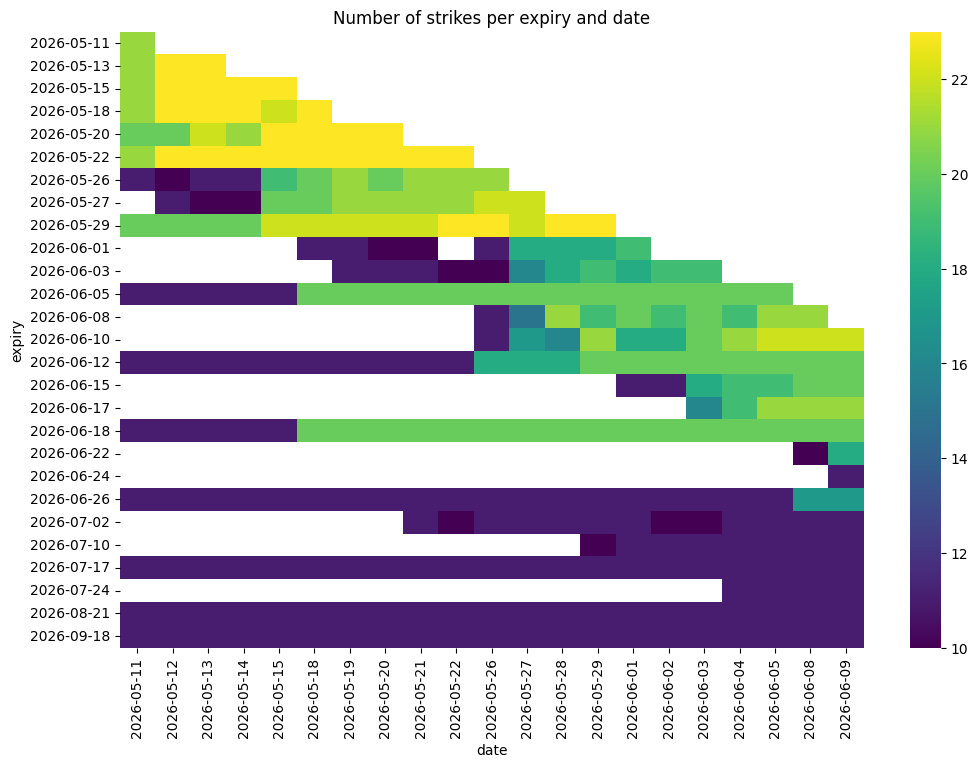

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = coverage.copy()

pivot["expiry"] = pivot["expiry"].dt.date
pivot["date"] = pivot["date"].dt.date

pivot = pivot.pivot(
    index="expiry",
    columns="date",
    values="n_strikes"
)


plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="viridis")
plt.title("Number of strikes per expiry and date")
plt.show()


In [17]:
# Ensure moneyness is in a range of [0.8,1.2]

MIN_MONEYNESS_LOW = 0.8
MIN_MONEYNESS_HIGH = 1.2

pct_good = (
    (coverage["min_moneyness"] >= MIN_MONEYNESS_LOW) &
    (coverage["max_moneyness"] <= MIN_MONEYNESS_HIGH)
).mean()

print(f"{pct_good:.1%} of expiries have full {MIN_MONEYNESS_LOW}–{MIN_MONEYNESS_HIGH} coverage")

100.0% of expiries have full 0.8–1.2 coverage


In [18]:
# Coverage green-light check

MIN_DATES = 20
MIN_EXPIRIES_PER_DATE = 10
MIN_STRIKES_PER_EXPIRY = 10
MIN_CONTRACTS_PER_DATE = 300
MIN_TOTAL_OBS = 5000
MIN_MONEYNESS_LOW = 0.8
MIN_MONEYNESS_HIGH = 1.2

date_summary = (
    coverage.groupby("date")
    .agg(
        n_expiries=("expiry", "nunique"),
        total_contracts=("n_contracts", "sum"),
        min_strikes_per_expiry=("n_strikes", "min"),
        median_strikes_per_expiry=("n_strikes", "median"),
        min_moneyness=("min_moneyness", "min"),
        max_moneyness=("max_moneyness", "max"),
    )
)

checks = {
    "At least 20 trading dates": coverage["date"].nunique() >= MIN_DATES,
    "Each date has at least 10 expiries": (date_summary["n_expiries"] >= MIN_EXPIRIES_PER_DATE).all(),
    "Each date has at least 300 contracts": (date_summary["total_contracts"] >= MIN_CONTRACTS_PER_DATE).all(),
    "Each date/expiry has at least 10 strikes": (coverage["n_strikes"] >= MIN_STRIKES_PER_EXPIRY).all(),
    "Total observations at least 5000": coverage["n_contracts"].sum() >= MIN_TOTAL_OBS,
    "Moneyness reaches at least 0.8 or below": (coverage["min_moneyness"] >= MIN_MONEYNESS_LOW).all(),
    "Moneyness reaches at least 1.2 or above": (coverage["max_moneyness"] <= MIN_MONEYNESS_HIGH).all(),
}

for name, passed in checks.items():
    print(("✅" if passed else "❌"), name)

if all(checks.values()):
    print("\n🟢 GREEN LIGHT: coverage is sufficient for daily volatility smile/surface fitting.")
else:
    print("\n🟡 Coverage is not perfect. Inspect failed checks before fitting surfaces.")

✅ At least 20 trading dates
✅ Each date has at least 10 expiries
✅ Each date has at least 300 contracts
✅ Each date/expiry has at least 10 strikes
✅ Total observations at least 5000
✅ Moneyness reaches at least 0.8 or below
✅ Moneyness reaches at least 1.2 or above

🟢 GREEN LIGHT: coverage is sufficient for daily volatility smile/surface fitting.



## 7. Black-Scholes pricing functions

Use these to compute implied volatility from market prices.

For real data, use the appropriate risk-free rate `r` and dividend yield `q`.


In [19]:

def bs_price(S, K, T, r, q, sigma, option_type):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * np.exp(-q*T) * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    elif option_type == "put":
        return K * np.exp(-r*T) * norm.cdf(-d2) - S * np.exp(-q*T) * norm.cdf(-d1)
    else:
        return np.nan


def no_arb_bounds(S, K, T, r, q, option_type):
    if option_type == "call":
        lower = max(S * np.exp(-q*T) - K * np.exp(-r*T), 0)
        upper = S * np.exp(-q*T)
    else:
        lower = max(K * np.exp(-r*T) - S * np.exp(-q*T), 0)
        upper = K * np.exp(-r*T)
    return lower, upper


def implied_vol(price, S, K, T, r, q, option_type, lo=1e-6, hi=5.0):
    lower, upper = no_arb_bounds(S, K, T, r, q, option_type)

    # Price outside arbitrage bounds cannot produce a valid Black-Scholes IV.
    if not (lower <= price <= upper):
        return np.nan

    def f(sig):
        return bs_price(S, K, T, r, q, sig, option_type) - price

    try:
        return brentq(f, lo, hi, maxiter=100)
    except ValueError:
        return np.nan



## 8. Check model-free no-arbitrage bounds

Before computing IVs, check whether option prices violate basic lower/upper bounds.


In [20]:

r = 0.04   # replace with suitable risk-free rate
q = 0.00   # replace with dividend yield if needed

bounds = liq.apply(
    lambda row: no_arb_bounds(
        row["underlying_price"], row["strike"], row["T"], r, q, row["option_type"]
    ),
    axis=1
)

tol = 0.01 * liq["market_price"]

liq["lower_bound"] = [b[0] for b in bounds]
liq["upper_bound"] = [b[1] for b in bounds]
liq["violates_bounds"] = (liq["market_price"] < liq["lower_bound"] - tol) | (liq["market_price"] > liq["upper_bound"] + tol)
liq["violates_bounds"].mean(), liq["violates_bounds"].sum()


(np.float64(0.05478775913129319), np.int64(444))

In [21]:
liq.groupby("date")["violates_bounds"].mean()

date
2026-05-11    0.048593
2026-05-12    0.020000
2026-05-13    0.045685
2026-05-14    0.013055
2026-05-15    0.033854
2026-05-18    0.098485
2026-05-19    0.108911
2026-05-20    0.047619
2026-05-21    0.063613
2026-05-22    0.041436
2026-05-26    0.013298
2026-05-27    0.053763
2026-05-28    0.161616
2026-05-29    0.113456
2026-06-01    0.008152
2026-06-02    0.131926
2026-06-03    0.045699
2026-06-04    0.010417
2026-06-05    0.005195
2026-06-08    0.015544
2026-06-09    0.061611
Name: violates_bounds, dtype: float64

In [22]:

liq[liq["violates_bounds"]].head()


,contract,option_type,strike,expiry,date,open,high,low,market_price,volume,vwap,transactions,underlying_price,T,moneyness,log_moneyness,lower_bound,upper_bound,violates_bounds
44,O:AAPL260513C00270000,call,270.0,2026-05-13,2026-05-11,21.43,23.50,21.08,21.89,219,22.5578,47,292.679993,0.005476,0.922509,-0.080658,22.739124,292.679993,True
49,O:AAPL260513C00275000,call,275.0,2026-05-13,2026-05-11,15.88,18.60,15.88,17.55,156,17.6629,34,292.679993,0.005476,0.939593,-0.062309,17.740219,292.679993,True
54,O:AAPL260513C00280000,call,280.0,2026-05-13,2026-05-11,10.97,13.77,10.97,12.20,49,12.2406,16,292.679993,0.005476,0.956676,-0.044290,12.741314,292.679993,True
61,O:AAPL260513C00285000,call,285.0,2026-05-13,2026-05-12,8.43,10.00,8.15,9.70,445,8.5244,43,294.799988,0.002738,0.966757,-0.033808,9.831198,294.799988,True
157,O:AAPL260513P00315000,put,315.0,2026-05-13,2026-05-11,21.85,21.85,21.85,21.85,1,21.8500,1,292.679993,0.005476,1.076261,0.073493,22.251021,314.931014,True



## 9. Compute implied volatilities

Large numbers of `NaN` IVs usually indicate:
- bad quotes,
- wrong underlying price,
- wrong date/time-to-expiry,
- wrong risk-free rate/dividend assumption,
- using last price instead of market_price price,
- stale or illiquid options.


In [23]:

iv_df = liq[~liq["violates_bounds"]].copy()

iv_df["IV"] = iv_df.apply(
    lambda row: implied_vol(
        price=row["market_price"],
        S=row["underlying_price"],
        K=row["strike"],
        T=row["T"],
        r=r,
        q=q,
        option_type=row["option_type"]
    ),
    axis=1
)

print("IV NaN rate:", iv_df["IV"].isna().mean())
iv_df["IV"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


IV NaN rate: 0.018929503916449087


count    7515.000000
mean        0.297385
std         0.134435
min         0.084919
1%          0.166062
5%          0.200537
50%         0.263200
95%         0.508567
99%         0.934657
max         2.027911
Name: IV, dtype: float64

In [24]:

iv_clean = iv_df[
    iv_df["IV"].notna() &
    iv_df["IV"].between(0.01, 3.00)
].copy()

print(f"Rows after valid IV filter: {len(iv_clean):,}")
print(f"Removed IV rows: {len(iv_df) - len(iv_clean):,}")


Rows after valid IV filter: 7,515
Removed IV rows: 145



## 10. Visualize smiles by maturity

A good dataset should produce reasonably smooth smiles/smirks. If each expiry gives a straight line, scattered mess, or impossible shape, inspect:
- whether moneyness is computed correctly,
- whether IV was already annualized,
- whether bid/ask columns are reversed,
- whether dates and expiry are parsed correctly.


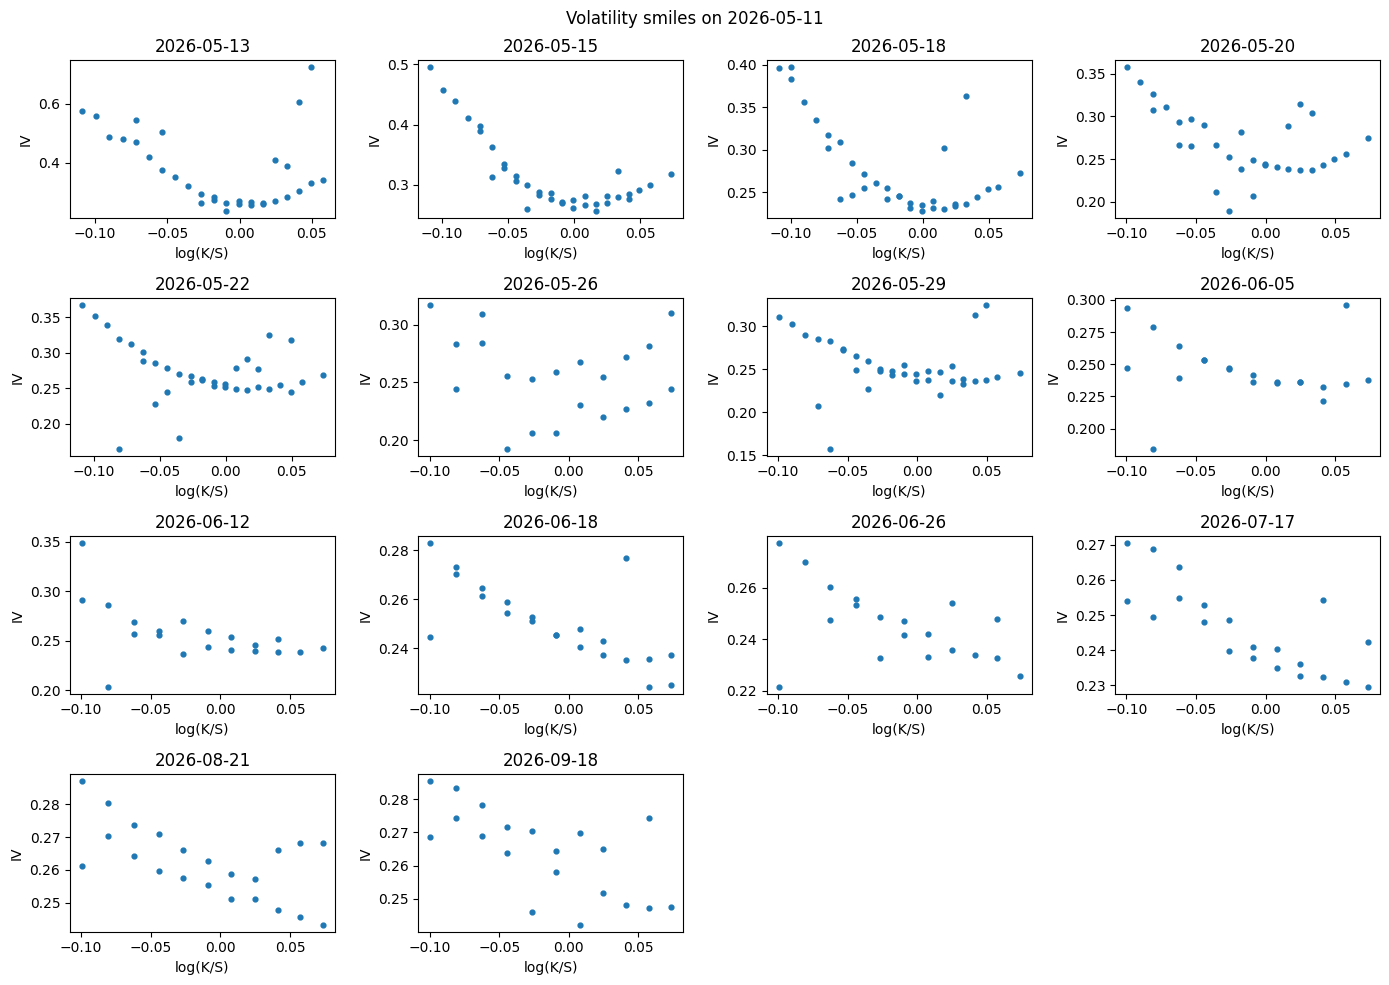

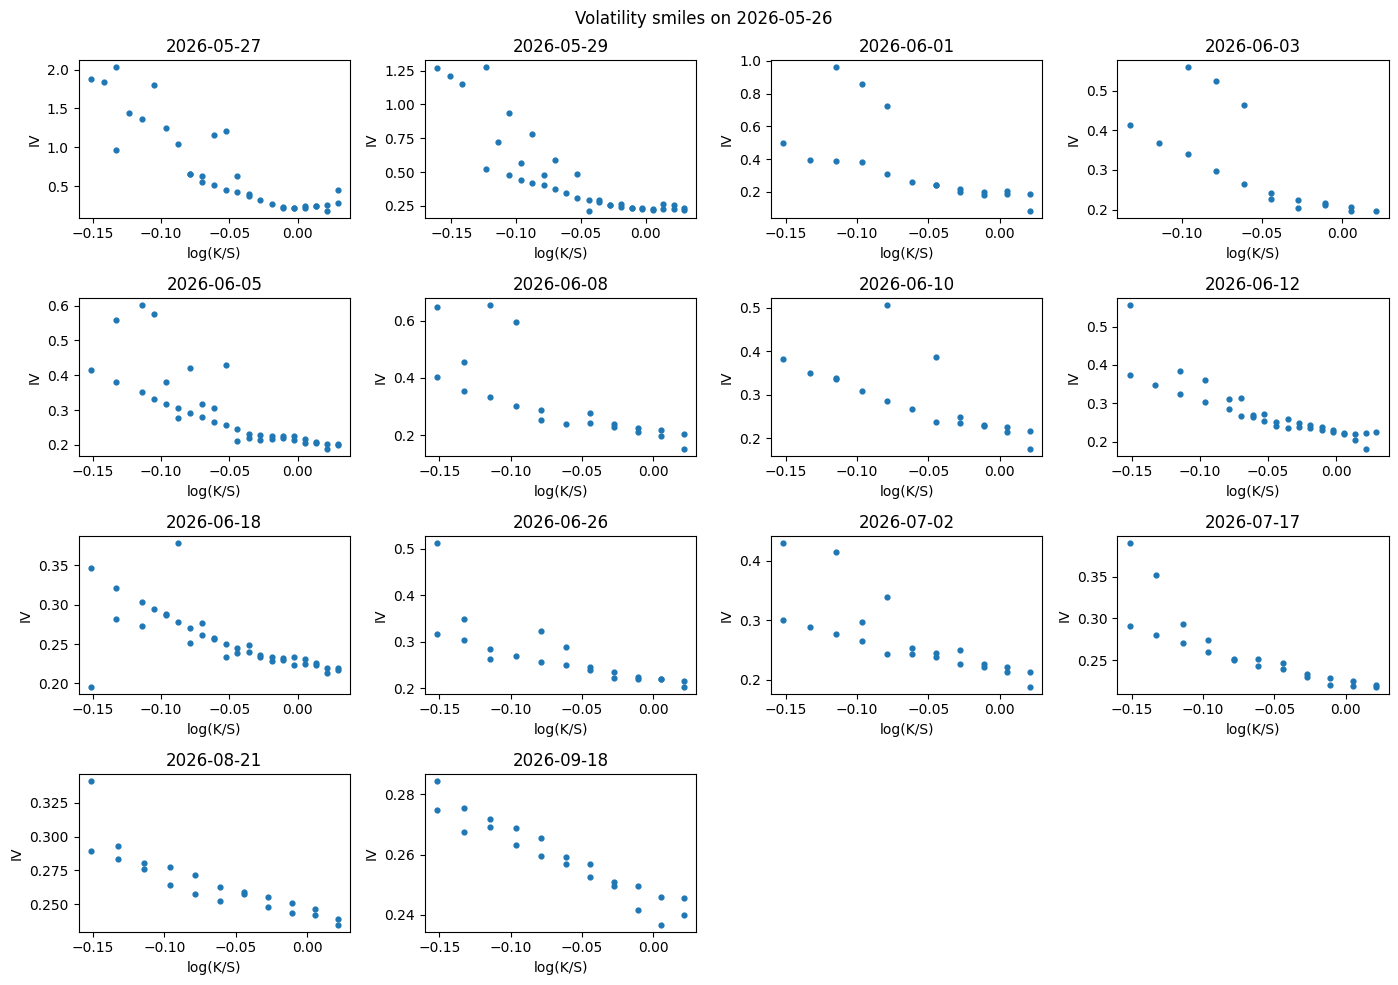

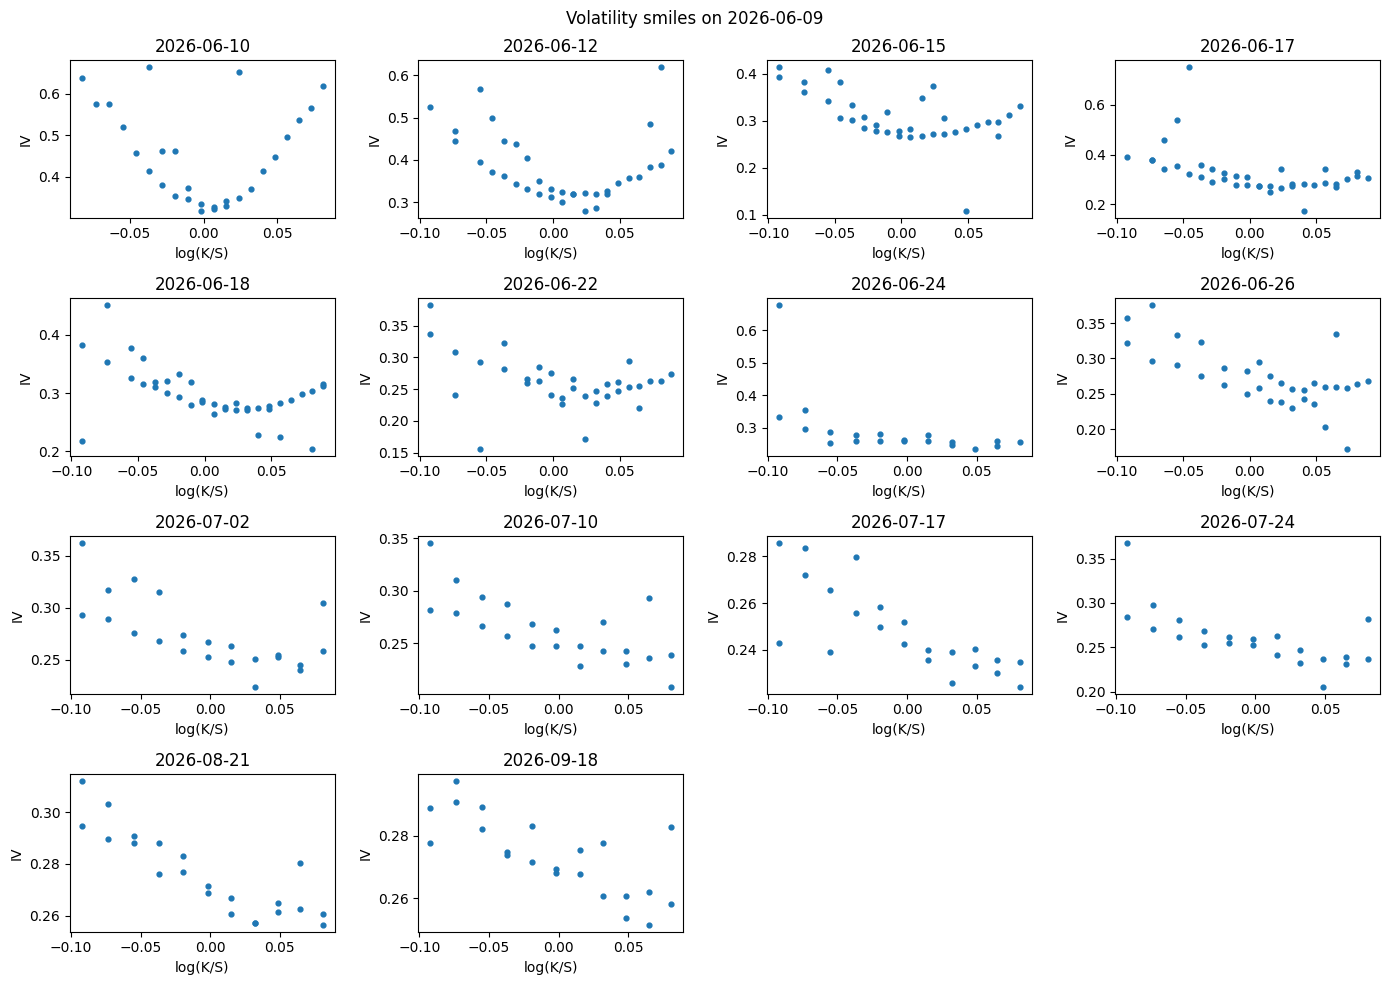

In [25]:
sample_dates = [
    iv_clean["date"].min(),
    iv_clean["date"].sort_values().unique()[len(iv_clean["date"].unique()) // 2],
    iv_clean["date"].max()
]

sample_dates = pd.to_datetime(sample_dates)

for date in sample_dates:
    date_iv_clean = iv_clean[iv_clean["date"] == date]

    expiries = sorted(date_iv_clean["expiry"].unique())

    fig, axes = plt.subplots(4, 4, figsize=(14, 10))
    axes = axes.flatten()

    for i, expiry in enumerate(expiries[:16]):
        sub = date_iv_clean[date_iv_clean["expiry"] == expiry].sort_values("log_moneyness")

        axes[i].scatter(sub["log_moneyness"], sub["IV"], s=12)
        axes[i].set_title(pd.to_datetime(expiry).strftime("%Y-%m-%d"))
        axes[i].set_xlabel("log(K/S)")
        axes[i].set_ylabel("IV")

    for j in range(len(expiries), len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Volatility smiles on {pd.to_datetime(date).strftime('%Y-%m-%d')}")
    plt.tight_layout()
    plt.show()
    plt.show()

In [26]:

from pathlib import Path

out_dir = Path("smile_plots")
out_dir.mkdir(exist_ok=True)

for date in sorted(iv_clean["date"].unique()):
    date_iv_clean = iv_clean[iv_clean["date"] == date]
    expiries = sorted(date_iv_clean["expiry"].unique())

    fig, axes = plt.subplots(4, 4, figsize=(14, 10))
    axes = axes.flatten()

    for i, expiry in enumerate(expiries[:16]):
        sub = date_iv_clean[date_iv_clean["expiry"] == expiry].sort_values("log_moneyness")

        axes[i].scatter(sub["log_moneyness"], sub["IV"], s=12)
        axes[i].set_title(pd.to_datetime(expiry).strftime("%Y-%m-%d"))

    for j in range(len(expiries), len(axes)):
        axes[j].axis("off")

    date_str = pd.to_datetime(date).strftime("%Y-%m-%d")
    fig.suptitle(f"Volatility smiles on {date_str}")
    plt.tight_layout()

    plt.savefig(out_dir / f"smiles_{date_str}.png", dpi=150)
    plt.close(fig)


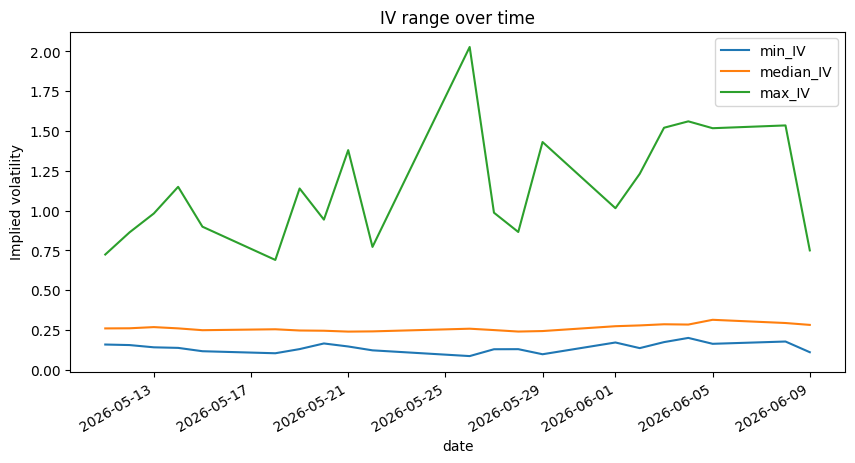

In [27]:
iv_summary = (
    iv_clean.groupby("date")
      .agg(
          min_IV=("IV", "min"),
          median_IV=("IV", "median"),
          max_IV=("IV", "max"),
          n_valid_IV=("IV", lambda x: x.notna().sum())
      )
)

iv_summary[["min_IV", "median_IV", "max_IV"]].plot(figsize=(10,5))
plt.title("IV range over time")
plt.ylabel("Implied volatility")
plt.show()


## 11. Static arbitrage sanity checks across strikes

For calls, price should be decreasing and convex in strike for a fixed expiry.

For puts, price should be increasing and convex in strike for a fixed expiry.

This is a discrete diagnostic, not a full proof of no arbitrage.


In [34]:

def check_strike_monotonicity_and_convexity(group):
    g = group.sort_values("strike").copy()
    K = g["strike"].values
    C = g["market_price"].values

    if len(g) < 3:
        return pd.Series({
            "n": len(g),
            "monotonic_violations": np.nan,
            "convexity_violations": np.nan,
        })

    if g["option_type"].iloc[0] == "call":
        mono_viol = np.sum(np.diff(C) > 1e-8)
    else:
        mono_viol = np.sum(np.diff(C) < -1e-8)

    # Approximate slope between neighboring strikes.
    slopes = np.diff(C) / np.diff(K)

    # Convexity means slopes should be nondecreasing.
    conv_viol = np.sum(np.diff(slopes) < -1e-8)

    return pd.Series({
        "n": len(g),
        "monotonic_violations": mono_viol,
        "convexity_violations": conv_viol,
    })


arb_by_expiry = (
    iv_clean.groupby(["date","expiry", "option_type"])
    .apply(check_strike_monotonicity_and_convexity)
    .reset_index()
)

arb_by_expiry.head(20)


/var/folders/5k/t6kz0v_x2gqbmd_6mhqwtbjh0000gn/T/ipykernel_2882/832229860.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(check_strike_monotonicity_and_convexity)


,date,expiry,option_type,n,monotonic_violations,convexity_violations
0,2026-05-11,2026-05-13,call,13,0,2
1,2026-05-11,2026-05-13,put,19,1,4
2,2026-05-11,2026-05-15,call,17,0,2
3,2026-05-11,2026-05-15,put,18,0,3
4,2026-05-11,2026-05-18,call,17,0,2
5,2026-05-11,2026-05-18,put,17,0,3
6,2026-05-11,2026-05-20,call,16,0,3
7,2026-05-11,2026-05-20,put,15,0,3
8,2026-05-11,2026-05-22,call,17,0,6
9,2026-05-11,2026-05-22,put,18,0,5


In [39]:
def check_strike_arbitrage(group, price_col="market_price", rel_tol=0.01):
    g = group.sort_values("strike").copy()
    
    prices = g[price_col].values
    strikes = g["strike"].values
    option_type = g["option_type"].iloc[0]

    if len(g) < 3:
        return pd.Series({
            "n": len(g),
            "monotonic_violations": np.nan,
            "convexity_violations": np.nan
        })

    # --- Monotonicity ---
    diffs = np.diff(prices)
    tol = rel_tol * prices[:-1]

    if option_type == "call":
        # Calls should decrease as strike increases
        monotonic_violations = np.sum(diffs > tol)
    else:
        # Puts should increase as strike increases
        monotonic_violations = np.sum(diffs < -tol)

    # --- Convexity ---
    slopes = np.diff(prices) / np.diff(strikes)
    slope_diffs = np.diff(slopes)

    # Relative tolerance scaled by nearby slope size
    tol_conv = rel_tol * np.maximum(np.abs(slopes[:-1]), 1e-8)

    convexity_violations = np.sum(slope_diffs < -tol_conv)

    return pd.Series({
        "n": len(g),
        "monotonic_violations": monotonic_violations,
        "convexity_violations": convexity_violations
    })


arb_by_slice = (
    df.groupby(["date", "expiry", "option_type"])
      .apply(check_strike_arbitrage)
      .reset_index()
)

arb_by_slice.head()

/var/folders/5k/t6kz0v_x2gqbmd_6mhqwtbjh0000gn/T/ipykernel_2882/3281913413.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(check_strike_arbitrage)


,date,expiry,option_type,n,monotonic_violations,convexity_violations
0,2026-05-11,2026-05-11,call,21,1,6
1,2026-05-11,2026-05-11,put,18,0,2
2,2026-05-11,2026-05-13,call,18,0,4
3,2026-05-11,2026-05-13,put,20,1,5
4,2026-05-11,2026-05-15,call,21,0,5


In [40]:
arb_by_slice["monotonicity_pass_rate"] = (
    1 - arb_by_slice["monotonic_violations"]/(arb_by_slice["n"]-1)
)

arb_by_slice["convexity_pass_rate"] = (
    1 - arb_by_slice["convexity_violations"]/(arb_by_slice["n"]-2)
)

arb_by_slice[[
    "monotonicity_pass_rate",
    "convexity_pass_rate"
]].describe()

,monotonicity_pass_rate,convexity_pass_rate
count,596.000000,596.000000
mean,0.983425,0.761271
std,0.038993,0.139942
min,0.722222,0.333333
25%,1.000000,0.666667
50%,1.000000,0.750000
75%,1.000000,0.888889
max,1.000000,1.000000


Most option slices satisfy monotonicity constraints, while convexity violations are present but relatively limited. The observed violations are likely attributable to market microstructure noise and the use of daily closing prices rather than synchronized bid-ask quotes. Overall, the data quality is sufficient for implied volatility estimation and subsequent arbitrage-free surface fitting.


## 12. Calendar arbitrage sanity check

For the same strike and option type, option price should generally not decrease as maturity increases.

Real market data may not have exactly matching strikes across expiries, so this check works best when strikes are shared.


In [53]:

def check_calendar_violations(df_in, price_col="market_price", rel_tol=0.01):
    rows = []

    for (date, option_type, strike), g in df_in.groupby(["date", "option_type", "strike"]):
        g = g.sort_values("T")

        if len(g) < 2:
            continue

        prices = g[price_col].values
        diffs = np.diff(prices)

        tol = rel_tol * prices[:-1]

        violations = np.sum(diffs < -tol)

        rows.append({
            "date": date,
            "option_type": option_type,
            "strike": strike,
            "n_maturities": len(g),
            "calendar_violations": violations,
        })

    return pd.DataFrame(rows)


calendar_check = check_calendar_violations(iv_clean)

calendar_check["violation_rate"] = (
    calendar_check["calendar_violations"]
    / (calendar_check["n_maturities"] - 1)
)

print("Total calendar violations:", calendar_check["calendar_violations"].sum())
print(
    "Percentage of strike slices with violations:",
    (calendar_check["calendar_violations"] > 0).mean().round(2)
)


Total calendar violations: 381
Percentage of strike slices with violations: 0.31


In [54]:
calendar_check["n_maturities"].describe()

count    854.000000
mean       8.750585
std        4.007009
min        2.000000
25%        5.000000
50%        8.000000
75%       13.000000
max       15.000000
Name: n_maturities, dtype: float64

In [55]:
(
    calendar_check["calendar_violations"] > 0
).groupby(calendar_check["n_maturities"]).mean()

n_maturities
2     0.243243
3     0.238095
4     0.244898
5     0.204082
6     0.214286
7     0.296875
8     0.387097
9     0.666667
10    0.521739
11    0.516129
12    0.590909
13    0.329193
14    0.260870
15    0.333333
Name: calendar_violations, dtype: float64

Calendar monotonicity checks on raw market prices produced a substantial number of violations. Inspection revealed that many strike slices contain only a small number of maturities and are based on daily closing prices rather than synchronized quotes. Consequently, these violations are attributed primarily to market microstructure noise. Calendar no-arbitrage will instead be enforced and assessed on the fitted volatility surface.


## 13. Put-call parity check

If you have both calls and puts at the same strike and expiry, check:

\[
C - P \approx S e^{-qT} - K e^{-rT}.
\]

Large violations suggest stale quotes, wrong underlying, wrong rates/dividends, or bad matching.


In [56]:

calls = iv_clean[iv_clean["option_type"] == "call"].copy()
puts = iv_clean[iv_clean["option_type"] == "put"].copy()

pc = calls.merge(
    puts,
    on=["date", "expiry", "strike"],
    suffixes=("_call", "_put")
)

if len(pc) > 0:
    pc["T"] = pc["T_call"]
    pc["S"] = pc["underlying_price_call"]

    pc["parity_rhs"] = (
        pc["S"] * np.exp(-q * pc["T"])
        - pc["strike"] * np.exp(-r * pc["T"])
    )

    pc["parity_lhs"] = pc["market_price_call"] - pc["market_price_put"]

    pc["parity_error"] = pc["parity_lhs"] - pc["parity_rhs"]
    pc["abs_parity_error"] = pc["parity_error"].abs()

    pc["relative_parity_error"] = (
        pc["abs_parity_error"]
        / pc[["market_price_call", "market_price_put"]].mean(axis=1)
    )

    display(
        pc[[
            "date", "expiry", "strike",
            "market_price_call", "market_price_put",
            "parity_lhs", "parity_rhs",
            "parity_error", "abs_parity_error",
            "relative_parity_error"
        ]].head()
    )

    display(pc[["abs_parity_error", "relative_parity_error"]].describe())

else:
    print("No matched call-put pairs found.")


,date,expiry,strike,market_price_call,market_price_put,parity_lhs,parity_rhs,parity_error,abs_parity_error,relative_parity_error
0,2026-05-11,2026-05-13,272.5,20.41,0.07,20.34,20.239671,0.100329,0.100329,0.009798
1,2026-05-11,2026-05-13,277.5,15.60,0.08,15.52,15.240766,0.279234,0.279234,0.035617
2,2026-05-12,2026-05-13,282.5,12.60,0.04,12.56,12.330924,0.229076,0.229076,0.036246
3,2026-05-11,2026-05-13,285.0,7.96,0.33,7.63,7.742409,-0.112409,0.112409,0.027119
4,2026-05-11,2026-05-13,287.5,5.90,0.60,5.30,5.242956,0.057044,0.057044,0.017552


,abs_parity_error,relative_parity_error
count,3254.000000,3254.000000
mean,0.599084,0.057869
std,1.046394,0.075222
min,0.000225,0.000018
25%,0.133035,0.015189
50%,0.321800,0.033556
75%,0.675040,0.070301
max,13.141541,0.846993


In [57]:
pc_summary_by_date = (
    pc.groupby("date")
      .agg(
          n_pairs=("strike", "count"),
          mean_abs_error=("abs_parity_error", "mean"),
          median_abs_error=("abs_parity_error", "median"),
          mean_relative_error=("relative_parity_error", "mean"),
          median_relative_error=("relative_parity_error", "median"),
      )
)

pc_summary_by_date

,n_pairs,mean_abs_error,median_abs_error,mean_relative_error,median_relative_error
date,,,,,
2026-05-11,157,0.498260,0.382361,0.056106,0.032238
2026-05-12,158,0.345640,0.222468,0.040980,0.024449
2026-05-13,163,0.380497,0.302305,0.044562,0.031416
2026-05-14,164,0.283308,0.184737,0.030958,0.022205
2026-05-15,163,0.423834,0.244237,0.044769,0.024538
2026-05-18,137,0.807498,0.552887,0.092835,0.060130
2026-05-19,135,0.717525,0.686120,0.087955,0.065718
2026-05-20,145,0.362435,0.220345,0.041053,0.024200
2026-05-21,152,0.298403,0.177285,0.035897,0.022349


Put-call parity was assessed by matching call and put options with identical strike prices, expiration dates, and observation dates. Across the dataset, absolute parity errors were generally small (below 0.1 for the vast majority of observations), and relative parity errors were typically well below 10%, with only a small number of observations approaching this threshold. The observed deviations are consistent with the use of daily closing prices rather than synchronized bid-ask quotes and are likely attributable to market microstructure effects and data noise. Overall, the results indicate that put-call parity is reasonably well satisfied and provide no evidence of systematic inconsistencies in the option prices or the underlying price merge.


## 14. Final data quality report

This gives a rough green/yellow/red status.

You should adapt the thresholds to the asset, market, and project goal.


In [63]:
report = {}

# Row counts
report["raw_rows"] = len(raw_df)
report["after_basic_cleaning"] = len(clean)
report["after_liquidity_filter"] = len(liq)
report["after_valid_iv_filter"] = len(iv_clean)

# Retention
report["basic_cleaning_retention"] = len(clean) / len(raw_df) if len(raw_df) else np.nan
report["liquidity_retention"] = len(liq) / len(clean) if len(clean) else np.nan
report["valid_iv_retention"] = len(iv_clean) / len(liq) if len(liq) else np.nan

# Time coverage
report["n_dates"] = iv_clean["date"].nunique()

# Expiry coverage
exp_per_date = iv_clean.groupby("date")["expiry"].nunique()

report["median_expiries_per_date"] = exp_per_date.median()
report["min_expiries_per_date"] = exp_per_date.min()
report["max_expiries_per_date"] = exp_per_date.max()

# Strike coverage
strikes_per_slice = (
    iv_clean.groupby(["date", "expiry"])["strike"]
    .nunique()
)

report["median_strikes_per_expiry"] = strikes_per_slice.median()
report["min_strikes_per_expiry"] = strikes_per_slice.min()
report["max_strikes_per_expiry"] = strikes_per_slice.max()

report["pct_slices_with_10_plus_strikes"] = (
    strikes_per_slice >= 10
).mean()

# Contracts
contracts_per_date = iv_clean.groupby("date").size()

report["median_contracts_per_date"] = contracts_per_date.median()
report["min_contracts_per_date"] = contracts_per_date.min()
report["max_contracts_per_date"] = contracts_per_date.max()

# IV diagnostics
report["iv_nan_rate_before_filter"] = (
    iv_df["IV"].isna().mean()
    if len(iv_df) else np.nan
)

# Arbitrage diagnostics
report["bound_violation_rate"] = (
    liq["violates_bounds"].mean()
    if len(liq) else np.nan
)

report_df = (
    pd.DataFrame.from_dict(
        report,
        orient="index",
        columns=["value"]
    )
)

report_df


,value
raw_rows,8725.000000
after_basic_cleaning,8184.000000
after_liquidity_filter,8104.000000
after_valid_iv_filter,7515.000000
basic_cleaning_retention,0.937994
liquidity_retention,0.990225
valid_iv_retention,0.927320
n_dates,21.000000
median_expiries_per_date,14.000000
min_expiries_per_date,13.000000


In [64]:

def quality_label(report):
    if report["after_valid_iv_filter"] < 5000:
        return "RED: too little usable data after IV filtering."

    if report["n_dates"] < 20:
        return "YELLOW/RED: too few trading dates for daily surface analysis."

    if report["min_expiries_per_date"] < 10:
        return "YELLOW/RED: at least one date has too few expiries."

    if report["pct_slices_with_10_plus_strikes"] < 0.95:
        return "YELLOW/RED: at least one date-expiry slice has too few strikes."

    if report["min_contracts_per_date"] < 300:
        return "YELLOW: at least one date has relatively few contracts."

    if report["bound_violation_rate"] > 0.10:
        return "YELLOW/RED: many prices violate basic no-arbitrage bounds."

    if report["iv_nan_rate_before_filter"] > 0.20:
        return "YELLOW: many IV failures; inspect prices, rates, dates, and underlying merge."

    return "GREEN LIGHT: data coverage and quality are sufficient for daily volatility surface fitting."

print(quality_label(report))


GREEN LIGHT: data coverage and quality are sufficient for daily volatility surface fitting.



## 15. Suggested next step

If the data passes these checks, save the cleaned IV data and then fit your surface.

For example:
- interpolate IV directly as a first exploratory step,
- fit SVI/SSVI/eSSVI total variance slices,
- enforce no-arbitrage constraints,
- compare fitted surface against market IVs,
- use the fitted surface for pricing/hedging experiments.


In [66]:

# Save cleaned data.
iv_clean.to_csv("clean_iv_surface_input.csv", index=False)
